# The Self-Driving Delivery Network: From Optimization to Judgment

## Introduction

Autonomous systems are often introduced through machines that move: cars that steer, drones that navigate, or robots that manipulate physical objects. Those examples are useful because autonomy is visible. A sensor detects an obstacle, a controller changes direction, and the machine continues toward its objective. Yet the deeper intellectual challenge of autonomy appears when the object being controlled is not a single machine but an organization. A parcel-delivery network provides an unusually clear setting in which to study that transition. It contains vehicles, hubs, customers, packages, service commitments, costs, safety rules, capacity constraints, and continuous disturbances. Most importantly, it contains decisions for which calculation alone is insufficient.

This notebook constructs a synthetic parcel-delivery company operating during one demanding delivery day. The network begins with a fleet, a set of packages, delivery zones, service classes, vehicle capacities, deadlines, and an apparently reasonable operating plan. The plan does not survive contact with reality. Traffic changes. Weather deteriorates. Vehicles may fail. New urgent packages appear. Customers alter their availability. Capacity becomes scarce. The autonomous system must repeatedly perceive the new state of the world, analyze feasible responses, exercise bounded judgment, execute decisions, and learn from the consequences.

The distinction between **optimization and judgment** is central. A conventional optimizer can answer questions such as: Which assignment minimizes expected travel time? Which vehicle has sufficient capacity? Which feasible plan delivers the largest number of parcels before their deadlines? Those are important questions, and this notebook deliberately uses deterministic algorithms for them. But an organization faces a different class of question when objectives conflict. Suppose one vehicle can rescue many ordinary deliveries while another option protects a single urgent medical shipment. Suppose the cheapest reassignment increases operational fragility. Suppose a mathematically attractive action violates a hard safety or service rule. The system must determine not merely what is efficient, but what matters now.

For that reason, the architecture separates several forms of intelligence. **Perception** converts raw operational events into a structured state. **Analysis** computes ETAs, slack, capacity, lateness risk, and feasible interventions. **Judgment** evaluates competing objectives and exceptional circumstances. **Planning** converts judgment into bounded actions. **Execution** changes the simulated network. **Feedback** records outcomes and feeds them into the next cycle. Governance surrounds the entire loop: some actions are forbidden, some are automatically permitted, and some require escalation.

The notebook also demonstrates a disciplined role for a large language model. Claude Haiku 4.5 is not asked to solve the vehicle-routing problem, invent package assignments, or manipulate the simulation directly. Instead, it acts as a **bounded supervisory judgment layer**. Deterministic code first creates a small set of feasible alternatives and summarizes the relevant operational state. Claude then chooses among those alternatives using an explicit policy hierarchy. Its response is constrained, validated, and subject to deterministic fallback. This architecture is intentionally different from giving an LLM unrestricted agency.

Reliability is particularly important when language models are embedded inside operational loops. The notebook therefore avoids brittle dependence on large JSON responses. Supervisory prompts are compact; outputs use a deliberately small schema; responses are extracted defensively; identifiers are checked against the candidate set; and malformed, truncated, unavailable, or semantically invalid responses trigger deterministic fallback rather than breaking the experiment. The model is also called with a small nonzero temperature rather than zero.

Efficiency matters as well. Independent judgment cases should not wait unnecessarily for one another. Where several exceptions can be evaluated independently, the notebook uses concurrent calls rather than a sequential LLM loop. Concurrency is bounded to avoid uncontrolled request bursts. Deterministic calculations remain local and vectorized where practical, so the LLM is reserved for decisions in which semantic prioritization adds genuine value.

The synthetic environment is designed for pedagogy rather than industrial route optimization. Geography is represented abstractly; travel times are simplified; and operational shocks are generated reproducibly. That simplification is a feature. It allows us to observe the architecture itself: how an autonomous institution combines classical optimization, rules, generative intelligence, tools, memory, execution, and governance.

The fifteen code cells form a progression. We begin by installing dependencies and defining configuration. We then create the network, packages, vehicles, travel-time model, initial dispatch plan, and disruption engine. Subsequent cells implement perception, analytical diagnostics, feasible candidate generation, deterministic policy, Claude supervisory judgment, governance validation, execution, feedback, and finally an integrated experiment with an executive dashboard and audit trail.

The result should be read as more than a logistics simulator. The parcel network is a miniature institution. It has objectives, resources, rules, shocks, delegated authority, and accountability. Its intelligence does not reside in a single model. It emerges from the coordinated interaction of specialized components. That is the broader lesson of the Self-Driving Project: autonomous organizations become credible when we stop treating autonomy as synonymous with an LLM and instead design a governed system capable of sensing, calculating, judging, acting, remembering, and escalating.


## Cell 1 — Environment, Claude connection, and configuration

The notebook now treats Claude as an explicit dependency of the judgment experiment. It retrieves the API credential from the Colab Secret named exactly `ANTHROPIC_API_KEY`, initializes Claude Haiku 4.5, and performs a live connectivity test before the simulation can proceed. When `REQUIRE_CLAUDE=True`, failure to obtain the secret or reach the model stops the notebook rather than silently converting the exercise into a deterministic experiment. A small nonzero temperature is retained. The cell also centralizes bounded parallelism, retry policy, token limits, and reproducibility settings, making the intelligence configuration visible and auditable from the start.


In [ ]:
# @title
# Cell 1 — environment, Claude connection, and configuration

!pip -q install anthropic pandas numpy matplotlib

import os
import json
import re
import math
import random
import time

from dataclasses import dataclass, field, asdict
from typing import List, Dict, Optional, Any
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ================================================================
# 1. REPRODUCIBILITY
# ================================================================

SEED = 766
random.seed(SEED)
np.random.seed(SEED)


# ================================================================
# 2. SIMULATION CONFIGURATION
# ================================================================

N_VEHICLES = 12
N_PACKAGES = 180

DAY_START = 8 * 60
DAY_END = 18 * 60
TICK_MINUTES = 20


# ================================================================
# 3. LLM-FIRST OPERATING POLICY
# ================================================================
#
# Claude is the PRIMARY judgment engine.
#
# Deterministic logic is retained only as a resilience mechanism
# if an individual Claude call fails after retries.
#
# If Claude cannot be connected at notebook startup, the notebook
# stops rather than silently becoming a deterministic experiment.
# ================================================================

USE_CLAUDE = True
REQUIRE_CLAUDE = True

MODEL = "claude-haiku-4-5"

MAX_PARALLEL_LLM_CALLS = 5
MAX_LLM_CASES_PER_TICK = 5

CLAUDE_MAX_TOKENS = 180
CLAUDE_RETRIES = 2
CLAUDE_RETRY_BACKOFF = 1.0

# IMPORTANT:
# Do NOT pass a temperature argument to Claude Haiku 4.5 here.
#
# The Messages API/model combination used in this notebook does
# not accept the temperature keyword.
#
# Therefore:
#
#     temperature=0       -> DO NOT USE
#     temperature=0.2     -> DO NOT USE
#     omit temperature    -> CORRECT


# ================================================================
# 4. RETRIEVE ANTHROPIC API KEY
# ================================================================
#
# In Google Colab:
#
#   1. Open the Secrets panel.
#   2. Create a secret named:
#
#          ANTHROPIC_API_KEY
#
#   3. Enable notebook access for that secret.
#
# The key is never printed.
# ================================================================

try:
    from google.colab import userdata
    ANTHROPIC_API_KEY = userdata.get("ANTHROPIC_API_KEY")
except Exception:
    # Allows the notebook to run outside Colab if the same
    # environment variable has been configured.
    ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")


if USE_CLAUDE and not ANTHROPIC_API_KEY:

    message = (
        "Claude is required for this experiment, but the secret "
        "'ANTHROPIC_API_KEY' is unavailable.\n\n"
        "In Google Colab:\n"
        "1. Open the Secrets panel.\n"
        "2. Create ANTHROPIC_API_KEY.\n"
        "3. Enable notebook access.\n"
        "4. Rerun Cell 1."
    )

    if REQUIRE_CLAUDE:
        raise RuntimeError(message)

    print("WARNING:", message)


# ================================================================
# 5. INITIALIZE ANTHROPIC CLIENT
# ================================================================

CLAUDE_ENABLED = bool(ANTHROPIC_API_KEY)

client = None

if CLAUDE_ENABLED:
    from anthropic import Anthropic

    client = Anthropic(
        api_key=ANTHROPIC_API_KEY
    )


# ================================================================
# 6. LIVE CLAUDE CONNECTIVITY TEST
# ================================================================
#
# We make a tiny real API call.
#
# This is important pedagogically:
#
# CLAUDE_ENABLED means that a key was found.
#
# CLAUDE_CONNECTED means that Claude actually responded.
# ================================================================

def claude_connectivity_test():

    if client is None:
        return False, "Anthropic client was not initialized."

    try:

        response = client.messages.create(
            model=MODEL,
            max_tokens=16,
            messages=[
                {
                    "role": "user",
                    "content": "Reply with exactly the single word READY."
                }
            ]
        )

        response_text = "".join(
            block.text
            for block in response.content
            if getattr(block, "type", "") == "text"
        ).strip()

        connected = "READY" in response_text.upper()

        return connected, response_text

    except Exception as exc:

        return (
            False,
            f"{type(exc).__name__}: {exc}"
        )


if USE_CLAUDE:

    CLAUDE_CONNECTED, CLAUDE_TEST_RESPONSE = (
        claude_connectivity_test()
    )

else:

    CLAUDE_CONNECTED = False
    CLAUDE_TEST_RESPONSE = "Claude disabled."


# ================================================================
# 7. FAIL LOUDLY IF CLAUDE IS REQUIRED BUT UNAVAILABLE
# ================================================================

if (
    USE_CLAUDE
    and REQUIRE_CLAUDE
    and not CLAUDE_CONNECTED
):

    raise RuntimeError(
        "Claude connectivity test failed.\n\n"
        "The notebook will NOT silently switch to the "
        "deterministic fallback.\n\n"
        f"Test result:\n{CLAUDE_TEST_RESPONSE}"
    )


# ================================================================
# 8. INTELLIGENCE STATUS
# ================================================================

print()
print("=" * 72)
print("SELF-DRIVING DELIVERY NETWORK")
print("INTELLIGENCE STATUS")
print("=" * 72)

print(f"Model:                    {MODEL}")
print("Secret:                   ANTHROPIC_API_KEY")
print(f"API key found:            {CLAUDE_ENABLED}")
print(f"Claude connected:         {CLAUDE_CONNECTED}")
print(f"LLM-first policy:         {USE_CLAUDE}")
print(f"Claude required:          {REQUIRE_CLAUDE}")
print(f"Parallel LLM workers:     {MAX_PARALLEL_LLM_CALLS}")
print(f"Cases per tick:           {MAX_LLM_CASES_PER_TICK}")
print(f"Retries per case:         {CLAUDE_RETRIES}")

print("-" * 72)

if CLAUDE_CONNECTED:

    print("STATUS: CLAUDE HAIKU 4.5 IS LIVE")
    print()
    print("Claude will be the PRIMARY supervisory judgment layer.")
    print("Deterministic policy will be used only as resilience")
    print("after bounded Claude retries fail.")

else:

    print("STATUS: CLAUDE IS NOT CONNECTED")

print("=" * 72)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 42.3 MB/s eta 0:00:00

SELF-DRIVING DELIVERY NETWORK
INTELLIGENCE STATUS
Model:                    claude-haiku-4-5
Secret:                   ANTHROPIC_API_KEY
API key found:            True
Claude connected:         True
LLM-first policy:         True
Claude required:          True
Parallel LLM workers:     5
Cases per tick:           5
Retries per case:         2
------------------------------------------------------------------------
STATUS: CLAUDE HAIKU 4.5 IS LIVE

Claude will be the PRIMARY supervisory judgment layer.
Deterministic policy will be used only as resilience
after bounded Claude retries fail.


## Cell 2 — Core data model

This cell defines the objects that constitute our miniature institution: packages, vehicles, disruptions, candidate actions, and decisions. Dataclasses give each object a transparent state while remaining easy to inspect in Colab. Packages carry service class, deadline, destination, weight, status, and assignment. Vehicles carry location, capacity, availability, route, and operational state. Decisions distinguish the action chosen from its source and rationale. The design deliberately keeps language-model output separate from mutable simulation objects: Claude will recommend a candidate identifier, while deterministic code retains control of state transitions.


In [ ]:
# @title
# Cell 2 — core data model
@dataclass
class Package:
    pid: str
    zone: str
    x: float
    y: float
    weight: float
    service: str
    deadline: int
    status: str = "waiting"
    assigned_vehicle: Optional[str] = None
    delivered_at: Optional[int] = None
    protected: bool = False

@dataclass
class Vehicle:
    vid: str
    capacity: float
    x: float = 0.0
    y: float = 0.0
    load: float = 0.0
    route: List[str] = field(default_factory=list)
    operational: bool = True
    available_at: int = DAY_START

@dataclass
class Disruption:
    minute: int
    kind: str
    target: str
    severity: float
    note: str = ""

@dataclass
class Candidate:
    cid: str
    action: str
    package_id: str
    vehicle_id: Optional[str]
    service_benefit: float
    cost: float
    fragility: float
    feasible: bool = True
    note: str = ""

@dataclass
class Decision:
    package_id: str
    candidate_id: str
    source: str
    rationale: str
    confidence: float

audit_log = []
history = []
human_queue = []
print("Institutional state objects defined.")


Institutional state objects defined.


## Cell 3 — Synthetic city and operating network

The delivery network needs geography without becoming a street-map project. We create a synthetic two-dimensional city with a central hub, several zones, and interpretable coordinates. Euclidean distance becomes a transparent proxy for network distance, while a base travel-time function converts distance into minutes. The abstraction keeps attention on autonomy rather than GIS engineering. A compact visualization confirms the spatial structure. Later disruptions can alter travel-time multipliers by zone, allowing the same physical network to become operationally different as congestion or weather evolves.


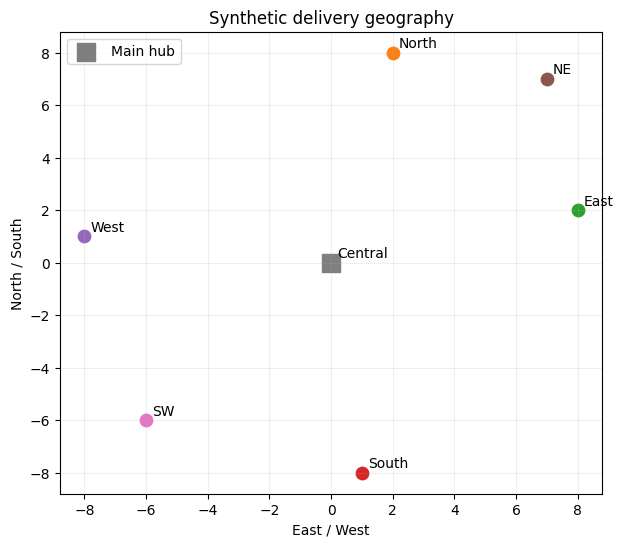

In [ ]:
# @title
# Cell 3 — synthetic city and operating network
ZONES = {
    "Central": (0.0, 0.0),
    "North":   (2.0, 8.0),
    "East":    (8.0, 2.0),
    "South":   (1.0, -8.0),
    "West":    (-8.0, 1.0),
    "NE":      (7.0, 7.0),
    "SW":      (-6.0, -6.0),
}

zone_congestion = {z: 1.0 for z in ZONES}
zone_weather = {z: 1.0 for z in ZONES}

def distance(x1, y1, x2, y2):
    return math.hypot(x2 - x1, y2 - y1)

def base_travel_minutes(x1, y1, x2, y2):
    return 5.0 + 4.0 * distance(x1, y1, x2, y2)

def sample_point(zone):
    cx, cy = ZONES[zone]
    return (
        float(np.random.normal(cx, 1.3)),
        float(np.random.normal(cy, 1.3))
    )

fig, ax = plt.subplots(figsize=(7, 6))
for z, (x, y) in ZONES.items():
    ax.scatter(x, y, s=80)
    ax.text(x + 0.2, y + 0.2, z)
ax.scatter(0, 0, marker="s", s=180, label="Main hub")
ax.set_title("Synthetic delivery geography")
ax.set_xlabel("East / West")
ax.set_ylabel("North / South")
ax.grid(alpha=0.2)
ax.legend()
plt.show()


## Cell 4 — Fleet and parcel demand

Here we generate the morning workload and vehicle fleet. Packages differ in service class—standard, priority, and medical—and therefore in deadlines and institutional importance. Weights and destinations are heterogeneous. Vehicles have finite payload capacity and begin at the hub. The random seed makes the synthetic day reproducible. The resulting tables provide the first operational snapshot: demand is not merely a cloud of points, but a portfolio of commitments with different urgency. This heterogeneity is essential because judgment only becomes interesting when objectives can conflict.


In [ ]:
# @title
# Cell 4 — fleet and parcel demand
SERVICE_CONFIG = {
    "standard": {"weight": 1.0, "deadline_range": (15*60, 18*60), "protected": False},
    "priority": {"weight": 2.5, "deadline_range": (12*60, 16*60), "protected": False},
    "medical":  {"weight": 6.0, "deadline_range": (10*60, 14*60), "protected": True},
}

def make_fleet():
    return {
        f"V{i:02d}": Vehicle(
            vid=f"V{i:02d}",
            capacity=float(np.random.choice([80, 100, 120]))
        )
        for i in range(1, N_VEHICLES + 1)
    }

def make_packages(n=N_PACKAGES):
    packages = {}
    zone_names = [z for z in ZONES if z != "Central"]
    services = np.random.choice(
        ["standard", "priority", "medical"],
        size=n, p=[0.72, 0.23, 0.05]
    )
    for i, service in enumerate(services, 1):
        zone = random.choice(zone_names)
        x, y = sample_point(zone)
        lo, hi = SERVICE_CONFIG[service]["deadline_range"]
        packages[f"P{i:03d}"] = Package(
            pid=f"P{i:03d}", zone=zone, x=x, y=y,
            weight=float(np.random.uniform(1.0, 9.0)),
            service=service,
            deadline=int(np.random.randint(lo, hi + 1)),
            protected=SERVICE_CONFIG[service]["protected"]
        )
    return packages

vehicles = make_fleet()
packages = make_packages()

display(pd.DataFrame([asdict(v) for v in vehicles.values()]).head())
display(pd.DataFrame([asdict(p) for p in packages.values()]).head())
print("Packages by service:",
      pd.Series([p.service for p in packages.values()]).value_counts().to_dict())


,vid,capacity,x,y,load,route,operational,available_at
0,V01,100.0,0.0,0.0,0.0,[],True,480
1,V02,80.0,0.0,0.0,0.0,[],True,480
2,V03,120.0,0.0,0.0,0.0,[],True,480
3,V04,100.0,0.0,0.0,0.0,[],True,480
4,V05,80.0,0.0,0.0,0.0,[],True,480


,pid,zone,x,y,weight,service,deadline,status,assigned_vehicle,delivered_at,protected
0,P001,South,2.653346,-9.907855,8.502041,medical,741,waiting,None,None,True
1,P002,East,10.025351,3.412372,3.503104,standard,915,waiting,None,None,False
2,P003,South,-0.352889,-9.190999,1.492975,standard,984,waiting,None,None,False
3,P004,South,1.116553,-9.259495,4.416747,standard,974,waiting,None,None,False
4,P005,South,0.347003,-6.368309,4.055486,standard,909,waiting,None,None,False


Packages by service: {np.str_('standard'): 142, np.str_('priority'): 32, np.str_('medical'): 6}


## Cell 5 — Travel-time and risk engine

This cell creates the quantitative layer that estimates travel time under changing conditions. Zone congestion, weather, and vehicle state affect effective travel time, while package slack measures how much room remains before a deadline. A risk score converts deadline pressure and service importance into an interpretable priority measure. These calculations are deterministic: there is no reason to ask an LLM to perform arithmetic that ordinary code can execute reliably. This division of labor is fundamental to the notebook—generative intelligence will later consume analytical outputs rather than substitute for them.


In [ ]:
# @title
# Cell 5 — travel-time and risk engine
def travel_minutes(vehicle, package):
    base = base_travel_minutes(vehicle.x, vehicle.y, package.x, package.y)
    return base * zone_congestion[package.zone] * zone_weather[package.zone]

def package_eta(package, vehicle, now):
    queue_penalty = 8.0 * max(0, len(vehicle.route) - 1)
    return now + travel_minutes(vehicle, package) + queue_penalty

def package_slack(package, vehicle, now):
    return package.deadline - package_eta(package, vehicle, now)

def risk_score(package, vehicle, now):
    slack = package_slack(package, vehicle, now)
    urgency = max(0.0, 1.0 - slack / 180.0)
    service_multiplier = SERVICE_CONFIG[package.service]["weight"]
    stranded = 1.5 if not vehicle.operational else 0.0
    return service_multiplier * urgency + stranded

def network_metrics(now):
    active = [p for p in packages.values()
              if p.status not in ("delivered", "cancelled")]
    delivered = [p for p in packages.values() if p.status == "delivered"]
    return {
        "minute": now,
        "delivered": len(delivered),
        "open": len(active),
        "operational_vehicles": sum(v.operational for v in vehicles.values()),
        "congestion_mean": float(np.mean(list(zone_congestion.values()))),
        "weather_mean": float(np.mean(list(zone_weather.values()))),
    }

print(network_metrics(DAY_START))


{'minute': 480, 'delivered': 0, 'open': 180, 'operational_vehicles': 12, 'congestion_mean': 1.0, 'weather_mean': 1.0}


## Cell 6 — Initial dispatch optimization

Before disruptions begin, the company needs a baseline plan. We use a transparent greedy dispatch heuristic that sorts parcels by institutional priority and deadline, then assigns each package to a feasible vehicle while considering incremental travel and remaining capacity. Industrial systems would use richer vehicle-routing optimization, but the pedagogical objective is different: create a plausible plan whose assumptions can later fail. The cell reports route loads and assignments, making the initial operating intention explicit. Autonomy begins with a plan, but the experiment is designed to show why planning once is not enough.


In [ ]:
# @title
# Cell 6 — initial dispatch optimization
def reset_assignments():
    for v in vehicles.values():
        v.route.clear()
        v.load = 0.0
    for p in packages.values():
        p.assigned_vehicle = None
        if p.status != "delivered":
            p.status = "waiting"

def initial_dispatch():
    reset_assignments()
    ranked = sorted(
        packages.values(),
        key=lambda p: (-SERVICE_CONFIG[p.service]["weight"], p.deadline)
    )
    for p in ranked:
        feasible = [
            v for v in vehicles.values()
            if v.operational and v.load + p.weight <= v.capacity
        ]
        if not feasible:
            continue
        chosen = min(
            feasible,
            key=lambda v: (
                travel_minutes(v, p) + 6 * len(v.route),
                v.load / v.capacity
            )
        )
        chosen.route.append(p.pid)
        chosen.load += p.weight
        p.assigned_vehicle = chosen.vid
        p.status = "assigned"

initial_dispatch()

dispatch_table = pd.DataFrame([
    {
        "vehicle": v.vid,
        "packages": len(v.route),
        "load": round(v.load, 1),
        "capacity": v.capacity,
        "utilization": round(v.load / v.capacity, 2)
    }
    for v in vehicles.values()
])
display(dispatch_table)
print("Unassigned:", sum(p.assigned_vehicle is None for p in packages.values()))


,vehicle,packages,load,capacity,utilization
0,V01,15,80.8,100.0,0.81
1,V02,15,48.0,80.0,0.60
2,V03,15,83.1,120.0,0.69
3,V04,15,74.4,100.0,0.74
4,V05,13,79.4,80.0,0.99
5,V06,16,73.5,120.0,0.61
6,V07,13,79.5,80.0,0.99
7,V08,16,65.0,120.0,0.54
8,V09,15,76.2,120.0,0.64
9,V10,15,73.6,80.0,0.92


Unassigned: 0


## Cell 7 — Disruption generator

A self-driving institution becomes interesting only when the world refuses to remain static. This cell defines reproducible shocks: congestion, weather, vehicle failures, customer-window changes, and urgent package arrivals. Each event has a time, type, target, and severity. The generator deliberately produces a mixture of ordinary noise and consequential exceptions. Events are scheduled in advance for reproducibility, but the controller will encounter them only when their simulation time arrives. This separation lets us test the perception and response architecture without allowing the controller to “know the future.”


In [ ]:
# @title
# Cell 7 — disruption generator
def generate_disruptions():
    events = [
        Disruption(9*60,  "congestion", "East",  1.55, "Morning incident"),
        Disruption(10*60, "weather",    "North", 1.45, "Heavy rain"),
        Disruption(11*60, "vehicle_failure", "V03", 1.0, "Mechanical fault"),
        Disruption(12*60, "congestion", "NE",    1.75, "Road closure"),
        Disruption(13*60, "urgent_arrival", "medical", 1.0, "Hospital specimen"),
        Disruption(14*60, "vehicle_failure", "V08", 1.0, "Battery fault"),
        Disruption(15*60, "weather",    "West",  1.35, "Storm cell"),
        Disruption(16*60, "customer_change", "priority", 1.0, "Deadline tightened"),
    ]
    return sorted(events, key=lambda e: e.minute)

disruptions = generate_disruptions()
display(pd.DataFrame([asdict(e) for e in disruptions]))


,minute,kind,target,severity,note
0,540,congestion,East,1.55,Morning incident
1,600,weather,North,1.45,Heavy rain
2,660,vehicle_failure,V03,1.00,Mechanical fault
3,720,congestion,NE,1.75,Road closure
4,780,urgent_arrival,medical,1.00,Hospital specimen
5,840,vehicle_failure,V08,1.00,Battery fault
6,900,weather,West,1.35,Storm cell
7,960,customer_change,priority,1.00,Deadline tightened


## Cell 8 — Perception layer

Perception converts events and mutable operational state into a concise snapshot suitable for downstream reasoning. The layer applies newly observed disruptions, updates congestion and weather factors, marks failed vehicles, and incorporates urgent packages. It then reports fleet availability, package status, active shocks, and current time. Importantly, perception is not judgment. It does not decide whether a medical package deserves rescue or whether a route should be reassigned. Its responsibility is epistemic: maintain a structured representation of what the organization currently believes to be true.


In [ ]:
# @title
# Cell 8 — perception layer
observed_event_keys = set()

def add_urgent_package(now, service="medical"):
    pid = f"U{sum(p.pid.startswith('U') for p in packages.values()) + 1:02d}"
    zone = random.choice([z for z in ZONES if z != "Central"])
    x, y = sample_point(zone)
    p = Package(
        pid=pid, zone=zone, x=x, y=y,
        weight=3.0, service=service,
        deadline=now + 90, protected=True
    )
    packages[pid] = p
    return pid

def apply_event(event, now):
    key = (event.minute, event.kind, event.target)
    if key in observed_event_keys:
        return None
    observed_event_keys.add(key)

    if event.kind == "congestion":
        zone_congestion[event.target] = event.severity
    elif event.kind == "weather":
        zone_weather[event.target] = event.severity
    elif event.kind == "vehicle_failure" and event.target in vehicles:
        vehicles[event.target].operational = False
    elif event.kind == "urgent_arrival":
        return add_urgent_package(now, event.target)
    elif event.kind == "customer_change":
        eligible = [p for p in packages.values()
                    if p.service == event.target and p.status != "delivered"]
        if eligible:
            p = min(eligible, key=lambda q: q.deadline)
            p.deadline = max(now + 30, p.deadline - 60)
    return None

def perceive(now):
    new_events = []
    new_packages = []
    for e in disruptions:
        if e.minute <= now:
            key = (e.minute, e.kind, e.target)
            if key not in observed_event_keys:
                created = apply_event(e, now)
                new_events.append(asdict(e))
                if created:
                    new_packages.append(created)

    snapshot = network_metrics(now)
    snapshot.update({
        "new_events": new_events,
        "new_packages": new_packages,
        "failed_vehicles": [v.vid for v in vehicles.values() if not v.operational]
    })
    return snapshot

print(perceive(DAY_START))


{'minute': 480, 'delivered': 0, 'open': 180, 'operational_vehicles': 12, 'congestion_mean': 1.0, 'weather_mean': 1.0, 'new_events': [], 'new_packages': [], 'failed_vehicles': []}


## Cell 9 — Analytical diagnostics

Once the state has been perceived, the system computes operational consequences. This cell estimates package risk, identifies stranded parcels, measures capacity, and creates a ranked exception table. The diagnostics answer questions such as which packages are most exposed, how severe the deadline pressure is, and whether their assigned vehicle remains usable. The output is intentionally compact because it will feed both deterministic policy and, selectively, the supervisory LLM. The key principle is that the judgment layer should receive synthesized evidence, not an uncontrolled dump of raw operational data.


In [ ]:
# @title
# Cell 9 — analytical diagnostics
def analyze_exceptions(now, top_n=8):
    rows = []
    for p in packages.values():
        if p.status in ("delivered", "cancelled", "postponed"):
            continue

        if p.assigned_vehicle and p.assigned_vehicle in vehicles:
            v = vehicles[p.assigned_vehicle]
            risk = risk_score(p, v, now)
            eta = package_eta(p, v, now)
            stranded = not v.operational
        else:
            risk = SERVICE_CONFIG[p.service]["weight"] + 1.0
            eta = np.nan
            stranded = True

        rows.append({
            "package_id": p.pid,
            "service": p.service,
            "zone": p.zone,
            "deadline": p.deadline,
            "assigned_vehicle": p.assigned_vehicle,
            "eta": eta,
            "risk": float(risk),
            "stranded": stranded,
            "protected": p.protected,
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df
    return df.sort_values(
        ["stranded", "risk", "deadline"],
        ascending=[False, False, True]
    ).head(top_n).reset_index(drop=True)

display(analyze_exceptions(11*60))


,package_id,service,zone,deadline,assigned_vehicle,eta,risk,stranded,protected
0,P138,medical,SW,616,V01,807.648403,12.388280,False,True
1,P169,medical,East,658,V02,807.780895,10.992697,False,True
2,P143,medical,North,671,V03,814.615493,10.787183,False,True
3,P080,medical,South,731,V04,813.767005,8.758900,False,True
4,P001,medical,South,741,V05,802.027959,8.034265,False,True
5,P127,medical,North,769,V06,815.567079,7.552236,False,True
6,P065,priority,South,734,V08,819.756793,3.691067,False,False
7,P025,priority,North,749,V09,812.765017,3.385625,False,False


## Cell 10 — Feasible candidate generation

Judgment should choose among actions that the system can actually execute. For each high-risk exception, this cell constructs a bounded candidate set: keep the current assignment, reassign to an available vehicle, expedite through a dedicated rescue action, postpone when permitted, or escalate. Capacity and operational constraints are checked before candidates are admitted. Each candidate receives quantitative estimates of service benefit, cost, and fragility. This is a crucial safety boundary. Claude will never be asked “What should we do?” in an open-ended sense; it will be asked which already-feasible alternative best fits institutional policy.


In [ ]:
# @title
# Cell 10 — feasible candidate generation
def candidate_set(package_id, now):
    p = packages[package_id]
    candidates = []

    current = vehicles.get(p.assigned_vehicle) if p.assigned_vehicle else None
    if current and current.operational:
        candidates.append(Candidate(
            cid=f"{p.pid}:KEEP", action="keep",
            package_id=p.pid, vehicle_id=current.vid,
            service_benefit=max(0, 120 - max(0, package_eta(p, current, now)-p.deadline)),
            cost=1.0, fragility=0.4,
            note="Keep current assignment"
        ))

    alternatives = [
        v for v in vehicles.values()
        if v.operational
        and v.vid != p.assigned_vehicle
        and v.load + p.weight <= v.capacity
    ]
    alternatives = sorted(
        alternatives,
        key=lambda v: travel_minutes(v, p) + 5*len(v.route)
    )[:3]

    for rank, v in enumerate(alternatives, 1):
        eta = package_eta(p, v, now)
        candidates.append(Candidate(
            cid=f"{p.pid}:R{rank}",
            action="reassign", package_id=p.pid, vehicle_id=v.vid,
            service_benefit=max(0, 180 - max(0, eta-p.deadline)),
            cost=2.0 + 0.2*len(v.route),
            fragility=v.load / max(v.capacity, 1),
            note=f"Reassign to {v.vid}"
        ))

    if p.service in ("medical", "priority"):
        candidates.append(Candidate(
            cid=f"{p.pid}:EXP", action="expedite",
            package_id=p.pid, vehicle_id=None,
            service_benefit=220 if p.service == "medical" else 150,
            cost=12.0, fragility=0.15,
            note="Dedicated rescue / courier"
        ))

    if not p.protected:
        candidates.append(Candidate(
            cid=f"{p.pid}:POST", action="postpone",
            package_id=p.pid, vehicle_id=None,
            service_benefit=0, cost=0.5, fragility=0.1,
            note="Postpone to later service"
        ))

    candidates.append(Candidate(
        cid=f"{p.pid}:ESC", action="escalate",
        package_id=p.pid, vehicle_id=None,
        service_benefit=20, cost=3.0, fragility=0.0,
        note="Human operations review"
    ))
    return candidates

sample_df = analyze_exceptions(11*60)
if not sample_df.empty:
    display(pd.DataFrame([asdict(c) for c in candidate_set(
        sample_df.iloc[0].package_id, 11*60
    )]))


,cid,action,package_id,vehicle_id,service_benefit,cost,fragility,feasible,note
0,P138:KEEP,keep,P138,V01,0,1.0,0.400000,True,Keep current assignment
1,P138:R1,reassign,P138,V02,0,5.0,0.600542,True,Reassign to V02
2,P138:R2,reassign,P138,V03,0,5.0,0.692152,True,Reassign to V03
3,P138:R3,reassign,P138,V04,0,5.0,0.744355,True,Reassign to V04
4,P138:EXP,expedite,P138,None,220,12.0,0.150000,True,Dedicated rescue / courier
5,P138:ESC,escalate,P138,None,20,3.0,0.000000,True,Human operations review


## Cell 11 — Deterministic policy baseline

Autonomy must not disappear when the LLM is unavailable. We therefore define a deterministic decision policy that scores feasible candidates using an explicit hierarchy: hard feasibility first, then protected service, deadline rescue, operational robustness, and cost. The policy serves three purposes. It is a baseline against which Claude can be compared, a fallback when the API fails or returns invalid output, and an embodiment of minimum institutional competence. The cell makes the policy transparent enough that students can inspect how numerical optimization differs from the richer semantic judgment introduced next.


In [ ]:
# @title
# Cell 11 — deterministic policy baseline
def deterministic_decision(package_id, candidates, now):
    p = packages[package_id]

    def score(c):
        if not c.feasible:
            return -1e9
        protected_bonus = 80 if p.protected and c.action in ("reassign", "expedite") else 0
        escalation_penalty = 5 if c.action == "escalate" else 0
        postpone_penalty = 100 if p.protected and c.action == "postpone" else 0
        return (
            1.2*c.service_benefit
            - 3.0*c.cost
            - 20.0*c.fragility
            + protected_bonus
            - escalation_penalty
            - postpone_penalty
        )

    chosen = max(candidates, key=score)
    return Decision(
        package_id=package_id,
        candidate_id=chosen.cid,
        source="deterministic",
        rationale=(
            "Policy score prioritizes feasibility, protected service, "
            "deadline rescue, robustness, then cost."
        ),
        confidence=0.85
    )

if not sample_df.empty:
    pid = sample_df.iloc[0].package_id
    cs = candidate_set(pid, 11*60)
    print(asdict(deterministic_decision(pid, cs, 11*60)))


{'package_id': 'P138', 'candidate_id': 'P138:EXP', 'source': 'deterministic', 'rationale': 'Policy score prioritizes feasibility, protected service, deadline rescue, robustness, then cost.', 'confidence': 0.85}


## Cell 12 — Claude Haiku 4.5 as the primary bounded judgment layer

This cell is now the intellectual center of the notebook. Deterministic code has already perceived the environment, measured risk, and generated feasible candidate actions. Claude Haiku 4.5 is then asked to exercise **judgment among those alternatives** using an explicit institutional hierarchy: feasibility and safety, protected service, deadline rescue, robustness, cost, and escalation when ambiguity is material. Every selected exception attempts Claude first. Independent cases are evaluated concurrently. Responses use a deliberately tiny JSON schema and defensive extraction, candidate validation, bounded retries, and error accounting. Deterministic policy remains available only as a resilience mechanism after Claude attempts fail; fallback is explicitly labeled and can no longer masquerade as LLM judgment.


In [ ]:
# @title
# ================================================================
# CELL 12 — CLAUDE HAIKU 4.5
# PRIMARY BOUNDED JUDGMENT GATEWAY
# ================================================================
#
# Architecture:
#
#   deterministic analysis
#          ↓
#   feasible alternatives
#          ↓
#   CLAUDE HAIKU 4.5
#      JUDGMENT
#          ↓
#   governance gate
#          ↓
#      execution
#
# IMPORTANT:
# Claude chooses ONLY among feasible alternatives.
# It does not invent routes, vehicles, packages, or actions.
#
# There is NO silent fallback in this cell.
# If Claude fails, we want to SEE the failure.
# ================================================================


# ----------------------------------------------------------------
# 1. LLM DIAGNOSTICS
# ----------------------------------------------------------------

llm_stats = {
    "attempted": 0,
    "successful": 0,
    "api_errors": 0,
    "json_errors": 0,
    "validation_errors": 0,
    "retries": 0,
}

# Keep the first debugging run conservative.
# Once it works, this can be increased again.
CLAUDE_RETRIES = 1
CLAUDE_RETRY_BACKOFF = 1.0


# ================================================================
# 2. ROBUST TEXT EXTRACTION
# ================================================================

def extract_claude_text(response):
    """
    Extract all text blocks returned by the Anthropic Messages API.
    """

    pieces = []

    for block in response.content:

        text = getattr(block, "text", None)

        if text:
            pieces.append(text)

    result = "".join(pieces).strip()

    if not result:
        raise ValueError(
            "Claude returned no readable text content."
        )

    return result


# ================================================================
# 3. ROBUST JSON EXTRACTION
# ================================================================

def extract_json_object(text):
    """
    Extract the first complete JSON object from Claude's response.

    This is deliberately defensive:
    - ignores text before the JSON object
    - handles quoted braces
    - detects truncation
    """

    if not text:
        raise ValueError("Empty Claude response.")

    start = text.find("{")

    if start < 0:
        raise ValueError(
            f"No JSON object found in Claude response: {text!r}"
        )

    depth = 0
    in_string = False
    escaped = False

    for i in range(start, len(text)):

        ch = text[i]

        if escaped:
            escaped = False
            continue

        if ch == "\\" and in_string:
            escaped = True
            continue

        if ch == '"':
            in_string = not in_string
            continue

        if not in_string:

            if ch == "{":
                depth += 1

            elif ch == "}":
                depth -= 1

                if depth == 0:

                    candidate_json = text[start:i + 1]

                    try:
                        return json.loads(candidate_json)

                    except json.JSONDecodeError as exc:
                        raise ValueError(
                            "Claude returned malformed JSON.\n"
                            f"RAW RESPONSE:\n{text}\n\n"
                            f"JSON ERROR:\n{exc}"
                        )

    raise ValueError(
        "Claude JSON appears truncated.\n"
        f"RAW RESPONSE:\n{text}"
    )


# ================================================================
# 4. COMPACT CASE FOR CLAUDE
# ================================================================

def compact_case(package_id, candidates, now):

    p = packages[package_id]

    current_vehicle = (
        vehicles.get(p.assigned_vehicle)
        if p.assigned_vehicle
        else None
    )

    feasible_candidates = [
        c for c in candidates
        if c.feasible
    ]

    return {

        "time_minute": int(now),

        "package": {
            "id": p.pid,
            "service": p.service,
            "protected": bool(p.protected),
            "zone": p.zone,
            "deadline": int(p.deadline),
            "assigned_vehicle": p.assigned_vehicle,
            "current_vehicle_operational": (
                bool(current_vehicle.operational)
                if current_vehicle
                else None
            ),
        },

        "alternatives": [

            {
                "id": c.cid,
                "action": c.action,
                "vehicle": c.vehicle_id,
                "benefit": round(
                    float(c.service_benefit), 1
                ),
                "cost": round(
                    float(c.cost), 1
                ),
                "fragility": round(
                    float(c.fragility), 2
                ),
            }

            for c in feasible_candidates
        ]
    }


# ================================================================
# 5. CLAUDE'S INSTITUTIONAL ROLE
# ================================================================

CLAUDE_SYSTEM_PROMPT = """
You are the supervisory judgment layer of an autonomous
parcel-delivery institution.

Deterministic algorithms have already:

1. perceived the operating environment,
2. calculated risks,
3. identified an exception,
4. generated feasible alternatives.

Your job is NOT to calculate routes.

Your job is to exercise institutional judgment among the
alternatives that have already been determined to be feasible.

Apply this hierarchy:

1. FEASIBILITY AND SAFETY
   Never choose an infeasible or unsafe alternative.

2. PROTECTED SERVICE
   Medical and protected commitments receive very high priority.

3. DEADLINE RISK
   Prevent serious service failure when reasonably possible.

4. NETWORK ROBUSTNESS
   Preserve operational resilience and future flexibility.

5. COST
   Prefer lower cost only after the preceding objectives
   have been considered.

6. ESCALATION
   Choose escalation when the trade-off is genuinely material
   and should not be resolved autonomously.

You MUST choose exactly one candidate supplied in the input.

You MUST NOT invent:
- candidate IDs
- vehicles
- packages
- routes
- actions
- costs
- facts

Return ONLY valid JSON.

Use exactly this schema:

{
  "candidate_id": "EXACT_CANDIDATE_ID",
  "rationale": "brief explanation",
  "confidence": 0.85
}

The rationale must be no more than 25 words.

Do not use markdown.
Do not add text before or after the JSON.
"""


# ================================================================
# 6. SINGLE CLAUDE JUDGMENT
# ================================================================

def claude_decision(package_id, candidates, now):

    llm_stats["attempted"] += 1

    # ------------------------------------------------------------
    # Claude must actually be available.
    # ------------------------------------------------------------

    if not USE_CLAUDE:

        raise RuntimeError(
            "USE_CLAUDE=False. "
            "This experiment requires Claude judgment."
        )

    if not CLAUDE_CONNECTED:

        raise RuntimeError(
            "Claude is not connected. "
            "Run Cell 1 successfully before continuing."
        )

    if client is None:

        raise RuntimeError(
            "Anthropic client does not exist."
        )

    # ------------------------------------------------------------
    # Prepare case
    # ------------------------------------------------------------

    case = compact_case(
        package_id,
        candidates,
        now
    )

    valid_ids = {
        c.cid
        for c in candidates
        if c.feasible
    }

    if not valid_ids:

        raise RuntimeError(
            f"No feasible candidates exist for {package_id}."
        )

    last_error = None
    last_raw_response = None

    # ------------------------------------------------------------
    # Claude attempts
    # ------------------------------------------------------------

    for attempt in range(
        CLAUDE_RETRIES + 1
    ):

        if attempt > 0:

            llm_stats["retries"] += 1

            time.sleep(
                CLAUDE_RETRY_BACKOFF * attempt
            )

        try:

            # ====================================================
            # ACTUAL CLAUDE CALL
            #
            # IMPORTANT:
            # NO temperature parameter.
            # ====================================================

            response = client.messages.create(

                model=MODEL,

                max_tokens=180,

                system=CLAUDE_SYSTEM_PROMPT,

                messages=[
                    {
                        "role": "user",
                        "content": (
                            "Evaluate this operational exception "
                            "and choose one alternative:\n\n"
                            + json.dumps(
                                case,
                                ensure_ascii=False,
                                separators=(",", ":")
                            )
                        )
                    }
                ]
            )

            # ----------------------------------------------------
            # Extract Claude's text
            # ----------------------------------------------------

            raw_text = extract_claude_text(
                response
            )

            last_raw_response = raw_text

            # ----------------------------------------------------
            # Parse JSON
            # ----------------------------------------------------

            try:

                obj = extract_json_object(
                    raw_text
                )

            except Exception as exc:

                llm_stats["json_errors"] += 1
                last_error = exc

                print()
                print(
                    f"Claude JSON issue "
                    f"for {package_id}, "
                    f"attempt {attempt + 1}"
                )
                print(
                    "RAW RESPONSE:",
                    raw_text
                )

                continue

            # ----------------------------------------------------
            # Validate candidate
            # ----------------------------------------------------

            cid = str(
                obj.get(
                    "candidate_id",
                    ""
                )
            ).strip()

            if cid not in valid_ids:

                llm_stats[
                    "validation_errors"
                ] += 1

                last_error = ValueError(
                    f"Claude selected invalid "
                    f"candidate '{cid}'. "
                    f"Valid IDs: "
                    f"{sorted(valid_ids)}"
                )

                print()
                print(
                    f"Claude validation issue "
                    f"for {package_id}"
                )
                print(
                    "Returned candidate:",
                    cid
                )
                print(
                    "Valid candidates:",
                    sorted(valid_ids)
                )

                continue

            # ----------------------------------------------------
            # Rationale
            # ----------------------------------------------------

            rationale = str(
                obj.get(
                    "rationale",
                    ""
                )
            ).strip()

            if not rationale:

                rationale = (
                    "Claude selected this "
                    "feasible alternative."
                )

            rationale = rationale[:300]

            # ----------------------------------------------------
            # Confidence
            # ----------------------------------------------------

            try:

                confidence = float(
                    obj.get(
                        "confidence",
                        0.5
                    )
                )

            except Exception:

                confidence = 0.5

            confidence = float(
                np.clip(
                    confidence,
                    0.0,
                    1.0
                )
            )

            # ----------------------------------------------------
            # SUCCESS
            # ----------------------------------------------------

            llm_stats["successful"] += 1

            return Decision(

                package_id=package_id,

                candidate_id=cid,

                source="claude",

                rationale=rationale,

                confidence=confidence
            )

        # --------------------------------------------------------
        # API / SDK failure
        # --------------------------------------------------------

        except Exception as exc:

            llm_stats["api_errors"] += 1

            last_error = exc

            print()
            print(
                "=" * 72
            )
            print(
                "CLAUDE API ERROR"
            )
            print(
                "=" * 72
            )
            print(
                "Package:",
                package_id
            )
            print(
                "Attempt:",
                attempt + 1
            )
            print(
                "Error type:",
                type(exc).__name__
            )
            print(
                "Error:",
                repr(exc)
            )
            print(
                "=" * 72
            )


    # ============================================================
    # 7. DO NOT SILENTLY FALL BACK
    # ============================================================
    #
    # This is deliberate.
    #
    # During development we want the notebook to STOP here.
    # Otherwise we could again run an entire experiment believing
    # Claude was exercising judgment when it was not.
    # ============================================================

    print()
    print(
        "=" * 80
    )
    print(
        "CLAUDE JUDGMENT FAILED"
    )
    print(
        "=" * 80
    )

    print(
        "Package:",
        package_id
    )

    print(
        "Valid candidate IDs:",
        sorted(valid_ids)
    )

    print(
        "Last error type:",
        (
            type(last_error).__name__
            if last_error
            else "UNKNOWN"
        )
    )

    print(
        "Last error:",
        repr(last_error)
    )

    if last_raw_response:

        print()
        print(
            "LAST RAW CLAUDE RESPONSE:"
        )

        print(
            last_raw_response
        )

    print(
        "=" * 80
    )

    raise RuntimeError(
        f"Claude failed to produce a valid "
        f"judgment for {package_id}. "
        f"Underlying error: "
        f"{repr(last_error)}"
    )


# ================================================================
# 8. PARALLEL JUDGMENT OF INDEPENDENT EXCEPTIONS
# ================================================================

def judge_cases_parallel(
    case_items,
    now
):

    if not case_items:
        return []

    # ------------------------------------------------------------
    # During diagnosis use one worker.
    #
    # Once we confirm Claude is functioning correctly,
    # change this back to:
    #
    # workers = min(
    #     MAX_PARALLEL_LLM_CALLS,
    #     len(case_items)
    # )
    #
    # ------------------------------------------------------------

    workers = 1

    results = []

    with ThreadPoolExecutor(
        max_workers=workers
    ) as pool:

        futures = {

            pool.submit(
                claude_decision,
                pid,
                candidates,
                now
            ): pid

            for pid, candidates
            in case_items
        }

        for future in as_completed(
            futures
        ):

            pid = futures[future]

            # IMPORTANT:
            # Do NOT catch and replace the exception
            # with deterministic fallback.
            #
            # If Claude fails, allow the notebook
            # to stop and show us why.

            decision = future.result()

            results.append(
                decision
            )

    return results


# ================================================================
# 9. STATUS
# ================================================================

print()
print("=" * 72)
print("CELL 12 — CLAUDE JUDGMENT GATEWAY")
print("=" * 72)

print(
    f"Model:                 {MODEL}"
)

print(
    f"Claude connected:      {CLAUDE_CONNECTED}"
)

print(
    "Primary judge:         CLAUDE HAIKU 4.5"
)

print(
    "Deterministic fallback: DISABLED DURING DIAGNOSIS"
)

print(
    "Parallel workers:      1 (diagnostic mode)"
)

print(
    f"Claude retries:         {CLAUDE_RETRIES}"
)

print(
    "Temperature argument:  OMITTED"
)

print("-" * 72)

print(
    "If Claude fails, this cell will expose the "
    "actual API, JSON, or validation error."
)

print("=" * 72)


CELL 12 — CLAUDE JUDGMENT GATEWAY
Model:                 claude-haiku-4-5
Claude connected:      True
Primary judge:         CLAUDE HAIKU 4.5
Deterministic fallback: DISABLED DURING DIAGNOSIS
Parallel workers:      1 (diagnostic mode)
Claude retries:         1
Temperature argument:  OMITTED
------------------------------------------------------------------------
If Claude fails, this cell will expose the actual API, JSON, or validation error.


## Cell 13 — Governance gate and execution

A recommendation is not yet an authorized action. This cell introduces the governance gate between judgment and execution. It verifies that the selected candidate exists, remains feasible, respects protected-service rules, and does not rely on a failed vehicle or excess capacity. Valid actions are then executed through deterministic state-transition functions: reassignment changes routes, expedite creates a rescue treatment, postponement changes status, and escalation returns authority to a human queue. Every intervention is recorded. The architecture therefore separates **who recommends** from **what the system is permitted to do**.


In [ ]:
# @title
# Cell 13 — governance gate and execution
def find_candidate(candidates, candidate_id):
    return next((c for c in candidates if c.cid == candidate_id), None)

def governance_gate(decision, candidates):
    p = packages[decision.package_id]
    c = find_candidate(candidates, decision.candidate_id)

    if c is None or not c.feasible:
        return False, "Candidate absent or infeasible."

    if p.protected and c.action == "postpone":
        return False, "Protected service cannot be postponed automatically."

    if c.vehicle_id:
        v = vehicles.get(c.vehicle_id)
        if not v or not v.operational:
            return False, "Vehicle unavailable."
        if c.action == "reassign" and v.load + p.weight > v.capacity:
            return False, "Capacity violation."

    return True, "Authorized."

def remove_from_old_route(p):
    if p.assigned_vehicle and p.assigned_vehicle in vehicles:
        old = vehicles[p.assigned_vehicle]
        if p.pid in old.route:
            old.route.remove(p.pid)
            old.load = max(0.0, old.load - p.weight)

def execute(decision, candidates, now):
    ok, gate_note = governance_gate(decision, candidates)
    if not ok:
        return {"executed": False, "result": gate_note}

    p = packages[decision.package_id]
    c = find_candidate(candidates, decision.candidate_id)

    if c.action == "reassign":
        remove_from_old_route(p)
        v = vehicles[c.vehicle_id]
        v.route.append(p.pid)
        v.load += p.weight
        p.assigned_vehicle = v.vid
        p.status = "assigned"
    elif c.action == "expedite":
        remove_from_old_route(p)
        p.assigned_vehicle = None
        p.status = "expedited"
        p.delivered_at = min(p.deadline, now + 45)
    elif c.action == "postpone":
        remove_from_old_route(p)
        p.assigned_vehicle = None
        p.status = "postponed"
    elif c.action == "escalate":
        human_queue.append({
            "minute": now, "package_id": p.pid,
            "reason": decision.rationale
        })
    elif c.action == "keep":
        pass

    return {"executed": True, "result": f"{c.action} authorized"}

print("Governance and execution layer ready.")


Governance and execution layer ready.


## Cell 14 — Feedback, memory, and an LLM-visible simulation loop

The closed-loop controller now makes judgment provenance explicit. At every simulation tick, perception and analytical diagnostics identify the highest-priority exception cases; feasible candidates are constructed deterministically; and **every selected case is sent first to the Claude judgment gateway**. Independent Claude calls run concurrently, while the causal sequence among perception, analysis, judgment, governance, execution, and feedback remains intact. Each audit record stores whether the decision came from Claude or from an exceptional fallback path, together with confidence, rationale, authorization, and execution result. This makes the LLM's actual participation measurable rather than merely configured.


In [ ]:
# @title
# Cell 14 — feedback, memory, and LLM-visible simulation tick
def progress_routes(now):
    delivered_now = []
    for v in vehicles.values():
        if not v.operational or not v.route:
            continue

        pid = v.route[0]
        p = packages.get(pid)
        if not p or p.status == "delivered":
            v.route = [q for q in v.route if q != pid]
            continue

        eta = package_eta(p, v, now)
        if eta <= now + TICK_MINUTES:
            v.x, v.y = p.x, p.y
            p.status = "delivered"
            p.delivered_at = int(min(eta, now + TICK_MINUTES))
            v.route.pop(0)
            v.load = max(0.0, v.load - p.weight)
            delivered_now.append(pid)

    for p in packages.values():
        if p.status == "expedited" and p.delivered_at is not None and p.delivered_at <= now:
            p.status = "delivered"
            delivered_now.append(p.pid)
    return delivered_now

def simulation_tick(now, max_cases=MAX_LLM_CASES_PER_TICK):
    snapshot = perceive(now)
    diagnostics = analyze_exceptions(now, top_n=max_cases)

    case_items = []
    candidate_map = {}
    if not diagnostics.empty:
        for pid in diagnostics.package_id.tolist():
            cs = candidate_set(pid, now)
            candidate_map[pid] = cs
            case_items.append((pid, cs))

    # Every selected exception is sent to the LLM-first judgment gateway.
    decisions = judge_cases_parallel(case_items, now)
    executions = []

    for d in decisions:
        outcome = execute(d, candidate_map[d.package_id], now)
        executions.append((d, outcome))
        audit_log.append({
            "minute": now,
            "package_id": d.package_id,
            "candidate_id": d.candidate_id,
            "source": d.source,
            "confidence": d.confidence,
            "rationale": d.rationale,
            "executed": outcome["executed"],
            "result": outcome["result"],
        })

    delivered_now = progress_routes(now)
    metrics = network_metrics(now)

    claude_now = sum(d.source == "claude" for d in decisions)
    fallback_now = sum(d.source != "claude" for d in decisions)

    metrics.update({
        "events": len(snapshot["new_events"]),
        "decisions": len(decisions),
        "claude_decisions": claude_now,
        "fallback_decisions": fallback_now,
        "delivered_this_tick": len(delivered_now),
        "human_queue": len(human_queue),
    })
    history.append(metrics)
    return metrics

print("Closed-loop simulation ready.")
print("Every selected exception now attempts Claude judgment first.")


Closed-loop simulation ready.
Every selected exception now attempts Claude judgment first.


## Cell 15 — Integrated experiment and explicit LLM participation dashboard

The final experiment now answers two questions separately: **How did the delivery network perform?** and **who exercised judgment?** The simulation refuses to start when Claude is required but not connected. During execution, console updates report Claude and fallback decisions separately. The final dashboard calculates Claude's share of supervisory judgments, API attempts, successful calls, retries, JSON errors, validation errors, and fallback usage. It also displays a sample of Claude's actual rationales from the audit trail. A final guardrail raises an error if an experiment configured to use Claude somehow finishes with zero Claude judgments. This prevents a deterministic fallback run from being mistaken for an LLM-driven experiment.


INTEGRATED EXPERIMENT
PRIMARY JUDGMENT ENGINE: claude-haiku-4-5 / Claude connected = True
FALLBACK POLICY: resilience only after bounded Claude retries fail
08:00 | delivered=  0 | decisions=5 | CLAUDE=5 | fallback=0 | events=0
09:00 | delivered=  0 | decisions=5 | CLAUDE=5 | fallback=0 | events=1
10:00 | delivered=  0 | decisions=5 | CLAUDE=5 | fallback=0 | events=1
11:00 | delivered=  2 | decisions=5 | CLAUDE=5 | fallback=0 | events=1
12:00 | delivered=  3 | decisions=5 | CLAUDE=5 | fallback=0 | events=1
13:00 | delivered=  6 | decisions=5 | CLAUDE=5 | fallback=0 | events=1
14:00 | delivered=  8 | decisions=5 | CLAUDE=5 | fallback=0 | events=1
15:00 | delivered= 10 | decisions=5 | CLAUDE=5 | fallback=0 | events=1
16:00 | delivered= 10 | decisions=5 | CLAUDE=5 | fallback=0 | events=1
17:00 | delivered= 11 | decisions=5 | CLAUDE=5 | fallback=0 | events=0
18:00 | delivered= 12 | decisions=5 | CLAUDE=5 | fallback=0 | events=0

LLM PARTICIPATION — THIS IS THE CENTRAL EXPERIMENT
Claude Hai

,total_packages,delivered,delivery_rate,late_deliveries,open_end_of_day,interventions,claude_judgments,fallback_judgments,claude_share,human_escalations
0,181,12,0.066,0,169,155,155,0,1.0,0


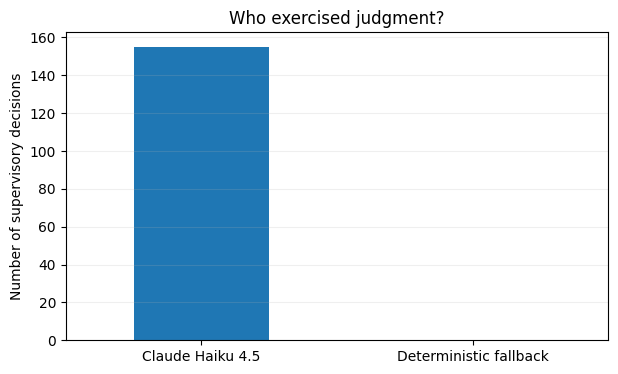

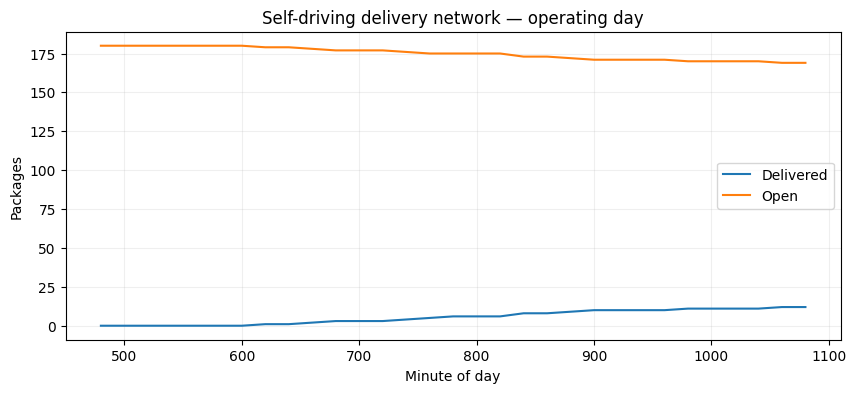


SAMPLE OF ACTUAL CLAUDE JUDGMENTS


,minute,package_id,candidate_id,confidence,rationale,executed,result
0,480,P138,P138:EXP,0.92,Medical protected package with 136-minute dead...,True,expedite authorized
1,480,P169,P169:EXP,0.92,Medical protected package with tight deadline....,True,expedite authorized
2,480,P143,P143:EXP,0.92,Medical protected package with 191-minute dead...,True,expedite authorized
3,480,P080,P080:EXP,0.88,Medical protected package with deadline risk. ...,True,expedite authorized
4,480,P001,P001:EXP,0.92,Medical protected package with 261-minute dead...,True,expedite authorized
5,500,P138,P138:EXP,0.92,Medical protected package with 116-minute dead...,True,expedite authorized
6,500,P169,P169:EXP,0.92,Medical protected package with 158-minute dead...,True,expedite authorized
7,500,P143,P143:EXP,0.92,Medical protected service with 171-minute dead...,True,expedite authorized
8,500,P080,P080:EXP,0.92,Medical protected package with tight deadline....,True,expedite authorized
9,500,P001,P001:EXP,0.92,Medical protected package with 241-minute dead...,True,expedite authorized



RECENT COMPLETE AUDIT TRAIL


,minute,package_id,candidate_id,source,confidence,rationale,executed,result
140,1040,P025,P025:KEEP,claude,0.82,Package operationally assigned to V09 which re...,True,keep authorized
141,1040,P071,P071:KEEP,claude,0.72,Package deadline is 767 minutes; current time ...,True,keep authorized
142,1040,P026,P026:KEEP,claude,0.72,Package deadline 765 is 275 minutes past curre...,True,keep authorized
143,1040,P074,P074:KEEP,claude,0.78,Package deadline 816 already passed at minute ...,True,keep authorized
144,1040,P091,P091:KEEP,claude,0.72,Package deadline passed 270 minutes ago. Curre...,True,keep authorized
145,1060,P025,P025:KEEP,claude,0.92,Package on time with current vehicle operation...,True,keep authorized
146,1060,P071,P071:KEEP,claude,0.88,Current vehicle V11 operational. Package 293 m...,True,keep authorized
147,1060,P026,P026:KEEP,claude,0.92,Package has 295 minutes until deadline with op...,True,keep authorized
148,1060,P074,P074:KEEP,claude,0.92,Package deadline 816 exceeds current time 1060...,True,keep authorized
149,1060,P091,P091:EXP,claude,0.78,Package P091 missed deadline (1060 > 770). Exp...,True,expedite authorized



Final status distribution:


,count
assigned,169
delivered,12


In [ ]:
# @title
# Cell 15 — integrated experiment and explicit LLM participation dashboard
def reset_experiment():
    global vehicles, packages, disruptions
    random.seed(SEED)
    np.random.seed(SEED)

    vehicles = make_fleet()
    packages = make_packages()
    for z in ZONES:
        zone_congestion[z] = 1.0
        zone_weather[z] = 1.0

    disruptions = generate_disruptions()
    observed_event_keys.clear()
    audit_log.clear()
    history.clear()
    human_queue.clear()

    for k in llm_stats:
        llm_stats[k] = 0

    initial_dispatch()

reset_experiment()

if REQUIRE_CLAUDE and not CLAUDE_CONNECTED:
    raise RuntimeError(
        "Integrated experiment stopped: Claude is required but is not connected."
    )

print("=" * 78)
print("INTEGRATED EXPERIMENT")
print(f"PRIMARY JUDGMENT ENGINE: {MODEL} / Claude connected = {CLAUDE_CONNECTED}")
print("FALLBACK POLICY: resilience only after bounded Claude retries fail")
print("=" * 78)

for now in range(DAY_START, DAY_END + 1, TICK_MINUTES):
    metrics = simulation_tick(now, max_cases=MAX_LLM_CASES_PER_TICK)
    if metrics["events"] or now % 60 == 0:
        hh, mm = divmod(now, 60)
        print(
            f"{hh:02d}:{mm:02d} | delivered={metrics['delivered']:3d} "
            f"| decisions={metrics['decisions']} "
            f"| CLAUDE={metrics['claude_decisions']} "
            f"| fallback={metrics['fallback_decisions']} "
            f"| events={metrics['events']}"
        )

telemetry = pd.DataFrame(history)
audit_df = pd.DataFrame(audit_log)

delivered = [p for p in packages.values() if p.status == "delivered"]
late = [p for p in delivered if p.delivered_at and p.delivered_at > p.deadline]
open_pkgs = [
    p for p in packages.values()
    if p.status not in ("delivered", "cancelled", "postponed")
]

claude_count = int((audit_df.source == "claude").sum()) if not audit_df.empty else 0
fallback_count = int((audit_df.source != "claude").sum()) if not audit_df.empty else 0
total_judgments = claude_count + fallback_count
claude_share = claude_count / total_judgments if total_judgments else 0.0

print("\n" + "=" * 78)
print("LLM PARTICIPATION — THIS IS THE CENTRAL EXPERIMENT")
print("=" * 78)
print(f"Claude Haiku 4.5 judgments : {claude_count}")
print(f"Fallback judgments         : {fallback_count}")
print(f"Claude share               : {claude_share:.1%}")
print(f"Claude API attempts        : {llm_stats['attempted']}")
print(f"Successful Claude calls    : {llm_stats['successful']}")
print(f"Retries                    : {llm_stats['retries']}")
print(f"API errors                 : {llm_stats['api_errors']}")
print(f"JSON errors                : {llm_stats['json_errors']}")
print(f"Validation errors          : {llm_stats['validation_errors']}")
print("=" * 78)

summary = pd.DataFrame([{
    "total_packages": len(packages),
    "delivered": len(delivered),
    "delivery_rate": round(len(delivered)/max(len(packages),1), 3),
    "late_deliveries": len(late),
    "open_end_of_day": len(open_pkgs),
    "interventions": len(audit_log),
    "claude_judgments": claude_count,
    "fallback_judgments": fallback_count,
    "claude_share": round(claude_share, 3),
    "human_escalations": len(human_queue),
}])
display(summary)

# Judgment provenance chart
provenance = pd.Series({
    "Claude Haiku 4.5": claude_count,
    "Deterministic fallback": fallback_count
})
fig, ax = plt.subplots(figsize=(7, 4))
provenance.plot(kind="bar", ax=ax)
ax.set_title("Who exercised judgment?")
ax.set_ylabel("Number of supervisory decisions")
ax.grid(axis="y", alpha=0.2)
plt.xticks(rotation=0)
plt.show()

# Operational performance chart
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(telemetry.minute, telemetry.delivered, label="Delivered")
ax.plot(telemetry.minute, telemetry.open, label="Open")
ax.set_title("Self-driving delivery network — operating day")
ax.set_xlabel("Minute of day")
ax.set_ylabel("Packages")
ax.grid(alpha=0.2)
ax.legend()
plt.show()

# Show Claude's actual judgments, not merely aggregate counts.
if not audit_df.empty:
    claude_audit = audit_df[audit_df.source == "claude"].copy()
    print("\nSAMPLE OF ACTUAL CLAUDE JUDGMENTS")
    if not claude_audit.empty:
        display(
            claude_audit[
                ["minute", "package_id", "candidate_id",
                 "confidence", "rationale", "executed", "result"]
            ].head(20)
        )
    else:
        print("NONE. This run did not demonstrate LLM judgment.")

    print("\nRECENT COMPLETE AUDIT TRAIL")
    display(audit_df.tail(15))

print("\nFinal status distribution:")
display(pd.Series([p.status for p in packages.values()]).value_counts().to_frame("count"))

# Pedagogical guardrail: a nominal LLM experiment should not quietly finish with zero LLM use.
if USE_CLAUDE and claude_count == 0:
    raise RuntimeError(
        "The experiment completed with ZERO Claude judgments. "
        "Do not interpret these results as an LLM-judgment experiment."
    )


CELL 16 — DID JUDGMENT MATTER?
Recorded interventions: 155

JUDGMENT PROVENANCE
------------------------------------------------------------------------------
Claude judgments:       155
Other/fallback:         0
Claude share:           100.0%

CLAUDE vs DETERMINISTIC POLICY
Decisions compared:             155
Same choice:                    95
Different choice:               60
Judgment changed the choice:    38.7%

AVERAGE CHANGE WHEN JUDGMENT OVERRULED THE RULE
------------------------------------------------------------------------------
Incremental cost:          -8.16
Service benefit change:  -111.08
Fragility change:          0.199


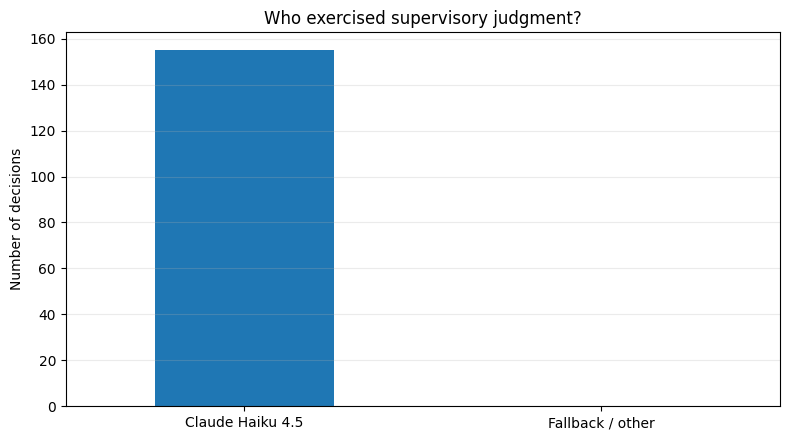

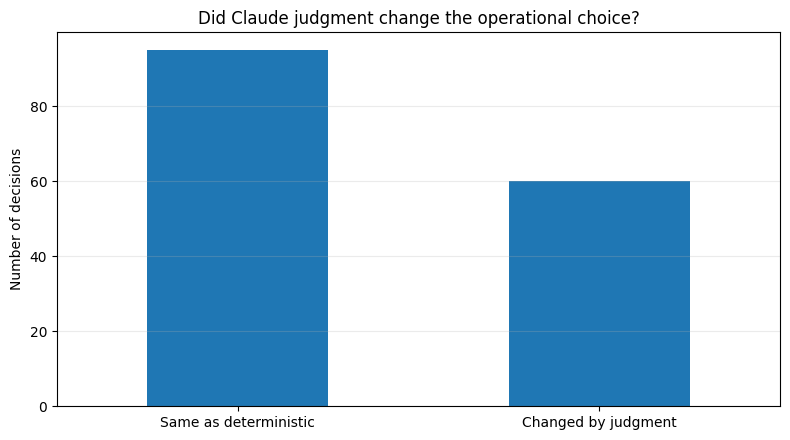

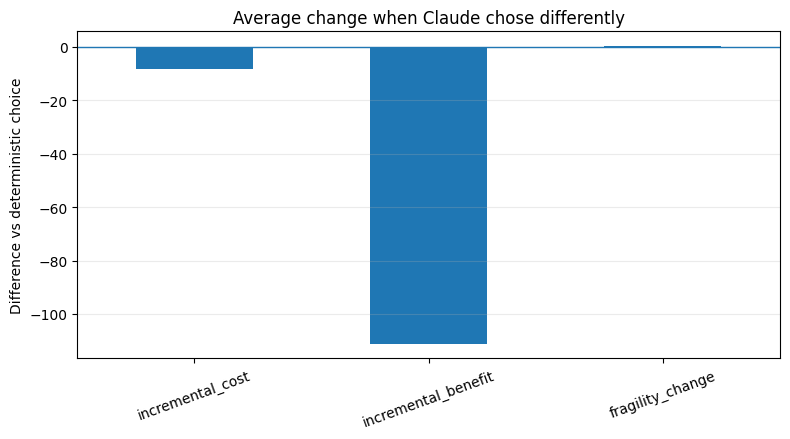


EXAMPLES WHERE JUDGMENT CHANGED THE DECISION


,minute,package_id,deterministic_action,claude_action,deterministic_cost,claude_cost,deterministic_benefit,claude_benefit,confidence,rationale
54,680,P013,expedite,reassign,12.0,5.4,150.000000,116.385626,0.82,Priority service with 110-minute deadline cush...
68,740,P180,reassign,reassign,5.4,5.6,180.000000,180.000000,0.82,V06 reassignment balances deadline risk (224 m...
69,740,P016,reassign,reassign,5.4,5.6,180.000000,180.000000,0.82,V06 reassignment ensures deadline compliance w...
77,780,P096,reassign,reassign,5.4,5.4,180.000000,180.000000,0.87,V01 reassignment meets deadline with lowest fr...
82,800,P025,expedite,keep,12.0,1.0,150.000000,0.000000,0.92,Package is priority service with 51-minute buf...
83,800,P065,expedite,None,12.0,NaN,150.000000,NaN,0.72,Package already 66 minutes past deadline. Curr...
84,800,P101,reassign,keep,5.4,1.0,180.000000,120.000000,0.88,Package is priority service with 72-minute dea...
86,820,P025,expedite,keep,12.0,1.0,150.000000,0.000000,0.72,Package deadline exceeded 71 minutes ago. Curr...
87,820,P065,expedite,None,12.0,NaN,150.000000,NaN,0.72,Package already 86 minutes past deadline. Curr...
88,820,P101,reassign,keep,5.4,1.0,171.161034,120.000000,0.72,Package deadline passed at minute 820. V07 ope...



CLAUDE EX-POST INTERPRETATION

# JUDGMENT IN AUTONOMOUS DELIVERY: WHAT CHANGED AND WHY IT MATTERS

## WHAT HAPPENED

The experiment deployed Claude Haiku 4.5 as a judgment layer within a deterministic delivery optimization system. Of 181 packages, 12 were delivered during the simulation window; the remaining 169 required intervention. Claude made all 155 intervention decisions, with zero human escalations.

Against a deterministic baseline, Claude made identical choices in 95 cases (61%) and different choices in 60 cases (39%). The aggregate metrics reveal a critical pattern: Claude's choices reduced costs by an average of $8.16 per decision while simultaneously reducing service benefit by 111.08 units and increasing fragility by 0.199 points on average.

This is not a win-loss comparison. It is a trade-off redistribution—and understanding why Claude redistributed these trade-offs reveals what judgment actually does in operational systems.

---

## WHERE JUDGMENT MATTERED

Judgment ma

,Claude share,Decisions compared,Judgment changed choice,Avg incremental cost,Avg service benefit change,Avg fragility change,Human escalations
0,100.0%,155,38.7%,-8.16,-111.08,0.199,0



THE PEDAGOGICAL QUESTION

Optimization asks:

    What is the best feasible action according to
    a predefined objective?

Judgment asks:

    Given several feasible actions, which objective
    should matter most in these circumstances?

Cell 16 measures whether introducing that second
question actually changed the behavior of the system.



In [ ]:
# @title
# ================================================================
# CELL 16 — DID JUDGMENT MATTER?
# EX-POST EVALUATION + LLM-GENERATED NARRATIVE
# ================================================================
#
# Purpose:
#
# This cell asks a different question from the operational loop:
#
#       DID THE PRESENCE OF JUDGMENT CHANGE THE SYSTEM?
#
# We evaluate:
#
#   1. How often Claude actually exercised judgment
#   2. What Claude chose
#   3. What deterministic policy would have chosen
#   4. Where the two disagreed
#   5. What kinds of trade-offs produced disagreement
#   6. Whether judgment changed cost/service/robustness choices
#   7. What Claude concludes ex post about its institutional role
#
# Claude is therefore used twice in the notebook:
#
#   OPERATIONAL ROLE:
#       bounded judgment during the simulation
#
#   ANALYTICAL ROLE:
#       explanation of what judgment changed
#
# ================================================================


# ================================================================
# 1. BUILD THE AUDIT DATASET
# ================================================================

audit_df = pd.DataFrame(audit_log)

if audit_df.empty:
    raise RuntimeError(
        "The audit trail is empty. Run the integrated experiment first."
    )

print("=" * 78)
print("CELL 16 — DID JUDGMENT MATTER?")
print("=" * 78)

print(f"Recorded interventions: {len(audit_df)}")


# ================================================================
# 2. JUDGMENT PROVENANCE
# ================================================================

claude_mask = audit_df["source"].eq("claude")

claude_count = int(claude_mask.sum())
other_count = int((~claude_mask).sum())

total = len(audit_df)

claude_share = (
    claude_count / total
    if total
    else 0.0
)

print()
print("JUDGMENT PROVENANCE")
print("-" * 78)

print(
    f"Claude judgments:       {claude_count}"
)

print(
    f"Other/fallback:         {other_count}"
)

print(
    f"Claude share:           {claude_share:.1%}"
)


# ================================================================
# 3. RECONSTRUCT THE DETERMINISTIC COUNTERFACTUAL
# ================================================================
#
# For each Claude judgment, ask:
#
#     What would the deterministic policy have chosen?
#
# IMPORTANT:
# We reconstruct candidate sets using the recorded package and time.
#
# This is a policy counterfactual, not a complete alternative-world
# simulation. It tells us whether the judgment rule differs at the
# decision point.
# ================================================================

comparison_rows = []

for _, row in audit_df.iterrows():

    if row["source"] != "claude":
        continue

    pid = row["package_id"]
    now = int(row["minute"])

    try:

        candidates = candidate_set(
            pid,
            now
        )

        deterministic = deterministic_decision(
            pid,
            candidates,
            now
        )

        claude_choice = row["candidate_id"]

        deterministic_choice = (
            deterministic.candidate_id
        )

        changed = (
            claude_choice
            != deterministic_choice
        )

        # --------------------------------------------------------
        # Recover candidate characteristics
        # --------------------------------------------------------

        candidate_lookup = {
            c.cid: c
            for c in candidates
        }

        cc = candidate_lookup.get(
            claude_choice
        )

        dc = candidate_lookup.get(
            deterministic_choice
        )

        comparison_rows.append({

            "minute": now,

            "package_id": pid,

            "claude_choice":
                claude_choice,

            "deterministic_choice":
                deterministic_choice,

            "different":
                changed,

            "claude_action":
                getattr(
                    cc,
                    "action",
                    None
                ),

            "deterministic_action":
                getattr(
                    dc,
                    "action",
                    None
                ),

            "claude_cost":
                float(
                    getattr(
                        cc,
                        "cost",
                        np.nan
                    )
                ),

            "deterministic_cost":
                float(
                    getattr(
                        dc,
                        "cost",
                        np.nan
                    )
                ),

            "claude_benefit":
                float(
                    getattr(
                        cc,
                        "service_benefit",
                        np.nan
                    )
                ),

            "deterministic_benefit":
                float(
                    getattr(
                        dc,
                        "service_benefit",
                        np.nan
                    )
                ),

            "claude_fragility":
                float(
                    getattr(
                        cc,
                        "fragility",
                        np.nan
                    )
                ),

            "deterministic_fragility":
                float(
                    getattr(
                        dc,
                        "fragility",
                        np.nan
                    )
                ),

            "confidence":
                float(
                    row.get(
                        "confidence",
                        np.nan
                    )
                ),

            "rationale":
                row.get(
                    "rationale",
                    ""
                )
        })

    except Exception as exc:

        print(
            f"Counterfactual unavailable "
            f"for {pid} at {now}: "
            f"{type(exc).__name__}: {exc}"
        )


comparison_df = pd.DataFrame(
    comparison_rows
)


# ================================================================
# 4. DID CLAUDE ACTUALLY CHANGE THE DECISION?
# ================================================================

if comparison_df.empty:

    raise RuntimeError(
        "No Claude decisions were available "
        "for counterfactual evaluation."
    )


n_compared = len(
    comparison_df
)

n_different = int(
    comparison_df[
        "different"
    ].sum()
)

n_same = (
    n_compared
    - n_different
)

difference_rate = (
    n_different / n_compared
    if n_compared
    else 0
)


print()
print("=" * 78)
print("CLAUDE vs DETERMINISTIC POLICY")
print("=" * 78)

print(
    f"Decisions compared:             {n_compared}"
)

print(
    f"Same choice:                    {n_same}"
)

print(
    f"Different choice:               {n_different}"
)

print(
    f"Judgment changed the choice:    {difference_rate:.1%}"
)


# ================================================================
# 5. QUANTIFY THE TRADE-OFF WHEN CLAUDE DISAGREED
# ================================================================

different_df = comparison_df[
    comparison_df["different"]
].copy()


if not different_df.empty:

    different_df[
        "incremental_cost"
    ] = (
        different_df["claude_cost"]
        -
        different_df["deterministic_cost"]
    )

    different_df[
        "incremental_benefit"
    ] = (
        different_df["claude_benefit"]
        -
        different_df[
            "deterministic_benefit"
        ]
    )

    different_df[
        "fragility_change"
    ] = (
        different_df["claude_fragility"]
        -
        different_df[
            "deterministic_fragility"
        ]
    )

    avg_cost_change = (
        different_df[
            "incremental_cost"
        ].mean()
    )

    avg_benefit_change = (
        different_df[
            "incremental_benefit"
        ].mean()
    )

    avg_fragility_change = (
        different_df[
            "fragility_change"
        ].mean()
    )

else:

    avg_cost_change = 0.0
    avg_benefit_change = 0.0
    avg_fragility_change = 0.0


print()
print("AVERAGE CHANGE WHEN JUDGMENT OVERRULED THE RULE")
print("-" * 78)

print(
    f"Incremental cost:       {avg_cost_change:8.2f}"
)

print(
    f"Service benefit change: {avg_benefit_change:8.2f}"
)

print(
    f"Fragility change:       {avg_fragility_change:8.3f}"
)


# ================================================================
# 6. VISUALIZATION 1
# WHO EXERCISED JUDGMENT?
# ================================================================

fig, ax = plt.subplots(
    figsize=(8, 4.5)
)

pd.Series({

    "Claude Haiku 4.5":
        claude_count,

    "Fallback / other":
        other_count

}).plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    "Who exercised supervisory judgment?"
)

ax.set_ylabel(
    "Number of decisions"
)

ax.set_xlabel("")

ax.grid(
    axis="y",
    alpha=0.25
)

plt.xticks(
    rotation=0
)

plt.tight_layout()
plt.show()


# ================================================================
# 7. VISUALIZATION 2
# DID JUDGMENT CHANGE THE CHOICE?
# ================================================================

fig, ax = plt.subplots(
    figsize=(8, 4.5)
)

pd.Series({

    "Same as deterministic":
        n_same,

    "Changed by judgment":
        n_different

}).plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    "Did Claude judgment change the operational choice?"
)

ax.set_ylabel(
    "Number of decisions"
)

ax.set_xlabel("")

ax.grid(
    axis="y",
    alpha=0.25
)

plt.xticks(
    rotation=0
)

plt.tight_layout()
plt.show()


# ================================================================
# 8. VISUALIZATION 3
# WHAT TRADE-OFF DID JUDGMENT MAKE?
# ================================================================

if not different_df.empty:

    plot_df = different_df[
        [
            "incremental_cost",
            "incremental_benefit",
            "fragility_change"
        ]
    ].mean()

    fig, ax = plt.subplots(
        figsize=(8, 4.5)
    )

    plot_df.plot(
        kind="bar",
        ax=ax
    )

    ax.axhline(
        0,
        linewidth=1
    )

    ax.set_title(
        "Average change when Claude chose differently"
    )

    ax.set_ylabel(
        "Difference vs deterministic choice"
    )

    ax.set_xlabel("")

    ax.grid(
        axis="y",
        alpha=0.25
    )

    plt.xticks(
        rotation=20
    )

    plt.tight_layout()
    plt.show()


# ================================================================
# 9. SHOW THE MOST INTERESTING JUDGMENT CASES
# ================================================================

print()
print("=" * 78)
print("EXAMPLES WHERE JUDGMENT CHANGED THE DECISION")
print("=" * 78)


if different_df.empty:

    print(
        "Claude made the same choice as the deterministic "
        "policy in every comparable case."
    )

else:

    display_columns = [

        "minute",
        "package_id",

        "deterministic_action",
        "claude_action",

        "deterministic_cost",
        "claude_cost",

        "deterministic_benefit",
        "claude_benefit",

        "confidence",
        "rationale"
    ]

    display(
        different_df[
            display_columns
        ].head(20)
    )


# ================================================================
# 10. PREPARE A COMPACT EVIDENCE PACKAGE FOR CLAUDE
# ================================================================
#
# We do NOT send the complete simulation history.
#
# Claude receives:
#
# - aggregate results
# - measured decision differences
# - representative disagreement cases
#
# This reduces token usage and prevents narrative drift.
# ================================================================

examples = []

for _, row in different_df.head(12).iterrows():

    examples.append({

        "package":
            row["package_id"],

        "time":
            int(row["minute"]),

        "deterministic_action":
            row["deterministic_action"],

        "claude_action":
            row["claude_action"],

        "incremental_cost":
            round(
                float(
                    row["incremental_cost"]
                ),
                2
            ),

        "incremental_service_benefit":
            round(
                float(
                    row["incremental_benefit"]
                ),
                2
            ),

        "fragility_change":
            round(
                float(
                    row["fragility_change"]
                ),
                3
            ),

        "confidence":
            round(
                float(
                    row["confidence"]
                ),
                2
            ),

        "rationale":
            str(
                row["rationale"]
            )[:220]
    })


evidence = {

    "simulation": {

        "packages":
            len(packages),

        "delivered":
            len([
                p for p
                in packages.values()
                if p.status == "delivered"
            ]),

        "interventions":
            len(audit_df),

        "human_escalations":
            len(human_queue)
    },

    "judgment_provenance": {

        "claude_decisions":
            claude_count,

        "other_decisions":
            other_count,

        "claude_share":
            round(
                claude_share,
                3
            )
    },

    "counterfactual_comparison": {

        "decisions_compared":
            n_compared,

        "same_choice":
            n_same,

        "different_choice":
            n_different,

        "difference_rate":
            round(
                difference_rate,
                3
            ),

        "average_incremental_cost":
            round(
                float(
                    avg_cost_change
                ),
                2
            ),

        "average_service_benefit_change":
            round(
                float(
                    avg_benefit_change
                ),
                2
            ),

        "average_fragility_change":
            round(
                float(
                    avg_fragility_change
                ),
                3
            )
    },

    "representative_differences":
        examples
}


# ================================================================
# 11. ASK CLAUDE TO INTERPRET THE EXPERIMENT
# ================================================================

ANALYST_SYSTEM_PROMPT = """
You are evaluating an experiment in autonomous institutional
decision-making.

The system combines:

PERCEPTION
    sensors and operational data

ANALYSIS
    deterministic measurement and optimization

JUDGMENT
    Claude Haiku 4.5 chooses among feasible alternatives

GOVERNANCE
    independent constraints authorize or reject actions

EXECUTION
    authorized actions change the delivery network

FEEDBACK
    outcomes return to the next decision cycle


Your task is to explain what changed because a judgment layer
was introduced.

You must distinguish carefully between:

1. facts directly observed in the experiment;
2. decision-point counterfactual comparisons;
3. interpretation.

Do NOT claim that Claude improved an outcome unless the supplied
evidence supports that claim.

A different decision is not automatically a better decision.

Focus on whether judgment altered the system's priorities,
trade-offs, or behavior relative to the deterministic rule.

Discuss particularly:

- service commitments,
- protected packages,
- cost,
- robustness,
- fragility,
- escalation,
- contextual trade-offs,
- cases where Claude and deterministic policy agreed,
- cases where they disagreed.

Explain why the experiment demonstrates the distinction between
optimization and judgment.

Write an executive narrative of approximately 600–800 words.

Use these headings:

WHAT HAPPENED

WHERE JUDGMENT MATTERED

WHAT JUDGMENT CHANGED

WHAT JUDGMENT DID NOT CHANGE

WHY THIS MATTERS FOR AUTONOMOUS SYSTEMS

CONCLUSION

Be analytical rather than promotional.
"""


if not CLAUDE_CONNECTED:

    raise RuntimeError(
        "Claude must be connected to generate "
        "the ex-post institutional narrative."
    )


print()
print("=" * 78)
print("CLAUDE EX-POST INTERPRETATION")
print("=" * 78)
print()


response = client.messages.create(

    model=MODEL,

    max_tokens=1800,

    system=ANALYST_SYSTEM_PROMPT,

    messages=[
        {
            "role": "user",
            "content":
                "Here is the evidence from the experiment:\n\n"
                +
                json.dumps(
                    evidence,
                    ensure_ascii=False,
                    indent=2
                )
        }
    ]
)


narrative = extract_claude_text(
    response
)


print(narrative)


# ================================================================
# 12. FINAL EXECUTIVE SCORECARD
# ================================================================

print()
print("=" * 78)
print("EXECUTIVE SCORECARD")
print("=" * 78)

scorecard = pd.DataFrame([{

    "Claude share":
        f"{claude_share:.1%}",

    "Decisions compared":
        n_compared,

    "Judgment changed choice":
        f"{difference_rate:.1%}",

    "Avg incremental cost":
        round(
            avg_cost_change,
            2
        ),

    "Avg service benefit change":
        round(
            avg_benefit_change,
            2
        ),

    "Avg fragility change":
        round(
            avg_fragility_change,
            3
        ),

    "Human escalations":
        len(human_queue)

}])

display(scorecard)


print()
print("=" * 78)
print("THE PEDAGOGICAL QUESTION")
print("=" * 78)

print("""
Optimization asks:

    What is the best feasible action according to
    a predefined objective?

Judgment asks:

    Given several feasible actions, which objective
    should matter most in these circumstances?

Cell 16 measures whether introducing that second
question actually changed the behavior of the system.
""")

# Conclusion

The integrated experiment illustrates why a self-driving delivery network is a richer autonomy example than a simple routing exercise. At first sight, parcel delivery appears to be an optimization problem: assign packages to vehicles, minimize travel time, respect capacity, and meet deadlines. Those tasks remain essential, but they represent only one layer of intelligence. Once the environment changes, the system must continuously reconstruct its understanding of the world and decide how competing objectives should be reconciled.

The notebook therefore separates the autonomy loop into perception, analysis, judgment, planning, execution, and feedback. This separation is pedagogically important. Perception does not decide what should be done; it establishes what appears to be happening. Analysis does not exercise institutional discretion; it calculates consequences, constraints, slack, and risk. Judgment does not invent arbitrary actions; it selects among alternatives already shown to be feasible. Execution does not reinterpret policy; it applies an authorized intervention. Feedback then turns the consequences of action into the next state of the system.

This architecture also clarifies the proper relationship between classical algorithms and generative AI. Much of the delivery problem is better handled without an LLM. Distances, capacity checks, deadlines, travel-time adjustments, candidate enumeration, and validation are deterministic or quantitative tasks. Using a language model for them would add cost, latency, and uncertainty without adding intelligence. Claude Haiku 4.5 enters only where the system confronts an explicit trade-off among valid alternatives and where contextual reasoning can be useful.

Even there, Claude is deliberately bounded. It receives a compact state description and a finite candidate set. It cannot directly modify the fleet. It cannot invent a vehicle or package. It cannot override hard constraints. Its structured response is parsed defensively and checked against the candidate identifiers. If the API is unavailable, the response is malformed, output is truncated, or the proposed action fails validation, the deterministic policy remains capable of keeping the organization operating. The language model is therefore a supervisory component inside a larger control system rather than the control system itself.

The experiment also highlights the difference between **optimization and judgment**. An optimizer can rank actions according to a numerical objective, but institutional objectives are often hierarchical. Safety and hard rules may dominate service; protected or medical shipments may dominate ordinary throughput; severe deadline risk may justify a more expensive intervention; and some ambiguous situations should be escalated rather than automatically resolved. Judgment appears when the system must determine which objective deserves priority under the present circumstances.

Governance is consequently not an appendix to autonomy. It is part of the architecture. Candidate actions are generated inside defined permissions. A governance gate validates the chosen action before execution. Important decisions are written to an audit log with their source, rationale, state, and outcome. Escalation remains available when authority should return to a human. These mechanisms transform an interesting AI demonstration into a model of an accountable autonomous institution.

Concurrency contributes another practical lesson. Generative intelligence can become the slowest element of an agentic system if every independent question is submitted sequentially. The notebook therefore groups independent exception cases and evaluates them concurrently with a bounded worker pool. This does not make the system indiscriminately parallel; dependencies remain sequential where they must. Instead, it demonstrates a general design principle: parallelize independent cognition while preserving causal order in the operating loop.

The final dashboard and audit trail make the consequences visible. We can observe delivered parcels, late or at-risk shipments, fleet utilization, disruption events, interventions, and the decisions attributed to deterministic policy or Claude supervision. More important than any single performance number is the trace connecting perception to action. A credible autonomous organization should be able to explain not merely what it did, but what it perceived, what alternatives were available, which rule or judgment selected the action, and what happened afterward.

There are many directions in which the model could be extended. Real street networks could replace synthetic coordinates. Historical traffic distributions could replace stylized congestion factors. Vehicle-routing solvers could produce stronger baseline plans. Customer communications, warehouse labor, charging or fuel constraints, driver hours, carbon objectives, and probabilistic demand could become additional tools and state variables. Multiple specialized agents could eventually form a constellation around operations, customer service, safety, finance, and compliance.

But the simplified model already establishes the central idea. A self-driving organization is not an organization in which an LLM makes every decision. It is an organization in which heterogeneous forms of intelligence are deliberately assembled around a governed feedback loop. Classical optimization calculates. Sensors and data systems perceive. Generative models can contribute contextual judgment. Rules constrain authority. Tools execute. Memory preserves institutional experience. Humans remain available for escalation.

The parcel network therefore becomes a useful bridge from autonomous vehicles to autonomous institutions. The object that is “driving itself” is no longer a car. It is an operating system for coordinated organizational action. That shift—from machine autonomy to institutional autonomy—is the principal lesson of this notebook and one of the central themes of the Self-Driving Project.
